In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import random
import numpy as np
import torch

def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
import os
import numpy as np

data_dir = '/content/drive/MyDrive/FundamentofDS/processed/binary'

X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))

X_val   = np.load(os.path.join(data_dir, 'X_val.npy'))
y_val   = np.load(os.path.join(data_dir, 'y_val.npy'))

X_test  = np.load(os.path.join(data_dir, 'X_test.npy'))
y_test  = np.load(os.path.join(data_dir, 'y_test.npy'))

print(f"Loaded X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Loaded X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"Loaded X_test:  {X_test.shape}, y_test: {y_test.shape}")

Loaded X_train: (17418, 1000, 12), y_train: (17418,)
Loaded X_val:   (2183, 1000, 12), y_val: (2183,)
Loaded X_test:  (2198, 1000, 12), y_test: (2198,)


In [4]:
!git clone https://github.com/helme/ecg_ptbxl_benchmarking.git

Cloning into 'ecg_ptbxl_benchmarking'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 185 (delta 67), reused 40 (delta 40), pack-reused 89 (from 1)
Receiving objects: 100% (185/185), 46.06 MiB | 23.57 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [5]:
import sys
import os
import typing
import builtins
import torch
import torch.nn as nn

repo_code_dir = os.path.abspath('ecg_ptbxl_benchmarking/code')
if repo_code_dir not in sys.path:
    sys.path.insert(0, repo_code_dir)

def bn_drop_lin(n_in: int, n_out: int, bn: bool = True, p: float = 0., actn: nn.Module = None):
    "Sequence of batchnorm (optional), dropout (optional) and linear layer."
    layers = []
    if bn:
        layers.append(nn.BatchNorm1d(n_in))
    if p != 0:
        layers.append(nn.Dropout(p))
    layers.append(nn.Linear(n_in, n_out))
    if actn is not None:
        layers.append(actn)
    return layers

builtins.bn_drop_lin = bn_drop_lin

builtins.Collection = typing.Collection
builtins.Optional = typing.Optional
builtins.Floats = typing.Union[float, typing.Collection[float]]

try:
    import fastai.core
except ModuleNotFoundError:
    import fastai.imports
    sys.modules['fastai.core'] = fastai.imports

from models.inception1d import inception1d

In [6]:
if X_train.shape[-1] == 12:
    X_train = np.transpose(X_train, (0, 2, 1))
    X_val   = np.transpose(X_val, (0, 2, 1))
    X_test  = np.transpose(X_test, (0, 2, 1))

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (17418, 12, 1000), y_train shape: (17418,)


In [7]:
from torch.utils.data import Dataset, DataLoader

class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32 if len(y.shape) > 1 and y.shape[1] > 1 else torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(ECGDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader  = DataLoader(ECGDataset(X_test, y_test), batch_size=64, shuffle=False)

In [8]:
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

is_binary = len(y_train.shape) == 1 or y_train.shape[1] == 1
num_classes = 1 if is_binary else y_train.shape[1]

model = inception1d(
    num_classes=num_classes,
    input_channels=X_train.shape[1],
    kernel_size=40,
    depth=6
).to(device)

criterion = nn.BCEWithLogitsLoss() if is_binary else nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

In [9]:
epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)

        optimizer.zero_grad()
        preds = model(X_b)

        if is_binary:
            preds = preds.squeeze(-1)
            loss = criterion(preds, y_b.float())
        else:
            loss = criterion(preds, y_b)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_b)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            preds = model(X_b)

            if is_binary:
                preds = preds.squeeze(-1)
                loss = criterion(preds, y_b.float())
                predicted = (torch.sigmoid(preds) > 0.5).long()
            else:
                loss = criterion(preds, y_b)
                predicted = preds.argmax(dim=1)

            correct += (predicted == y_b).sum().item()
            val_loss += loss.item() * len(X_b)
            total += len(y_b)

    val_loss /= len(val_loader.dataset)
    val_acc = correct / total

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

Epoch 01/15 | Train Loss: 0.3643 | Val Loss: 0.3573 | Val Acc: 84.29%
Epoch 02/15 | Train Loss: 0.3201 | Val Loss: 0.3291 | Val Acc: 85.75%
Epoch 03/15 | Train Loss: 0.3091 | Val Loss: 0.3498 | Val Acc: 84.56%
Epoch 04/15 | Train Loss: 0.2994 | Val Loss: 0.3479 | Val Acc: 85.07%
Epoch 05/15 | Train Loss: 0.2924 | Val Loss: 0.3312 | Val Acc: 85.02%
Epoch 06/15 | Train Loss: 0.2893 | Val Loss: 0.3306 | Val Acc: 85.62%
Epoch 07/15 | Train Loss: 0.2850 | Val Loss: 0.3234 | Val Acc: 85.80%
Epoch 08/15 | Train Loss: 0.2767 | Val Loss: 0.3322 | Val Acc: 85.71%
Epoch 09/15 | Train Loss: 0.2732 | Val Loss: 0.3374 | Val Acc: 85.62%
Epoch 10/15 | Train Loss: 0.2684 | Val Loss: 0.3241 | Val Acc: 86.07%
Epoch 11/15 | Train Loss: 0.2661 | Val Loss: 0.3318 | Val Acc: 85.80%
Epoch 12/15 | Train Loss: 0.2622 | Val Loss: 0.3476 | Val Acc: 84.97%
Epoch 13/15 | Train Loss: 0.2517 | Val Loss: 0.3745 | Val Acc: 84.75%
Epoch 14/15 | Train Loss: 0.2482 | Val Loss: 0.3488 | Val Acc: 85.20%
Epoch 15/15 | Train 

In [10]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        preds = model(X_b)

        if is_binary:
            preds = preds.squeeze(-1)
            predicted = (torch.sigmoid(preds) > 0.5).long()
        else:
            predicted = preds.argmax(dim=1)

        correct += (predicted == y_b).sum().item()
        total += len(y_b)

test_acc = correct / total
print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 85.17%


In [11]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import torch

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        preds = model(X_b)

        if is_binary:
            preds = preds.squeeze(-1)
            probs = torch.sigmoid(preds)
            predicted = (probs > 0.5).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y_b.cpu().numpy())
        else:
            probs = torch.softmax(preds, dim=1)
            predicted = preds.argmax(dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y_b.cpu().numpy())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print("\n" + "="*50)
print("              CLASSIFICATION REPORT              ")
print("="*50)
print(classification_report(all_targets, all_preds, digits=4))


              CLASSIFICATION REPORT              
              precision    recall  f1-score   support

           0     0.8172    0.8297    0.8234       916
           1     0.8770    0.8674    0.8722      1282

    accuracy                         0.8517      2198
   macro avg     0.8471    0.8485    0.8478      2198
weighted avg     0.8521    0.8517    0.8518      2198



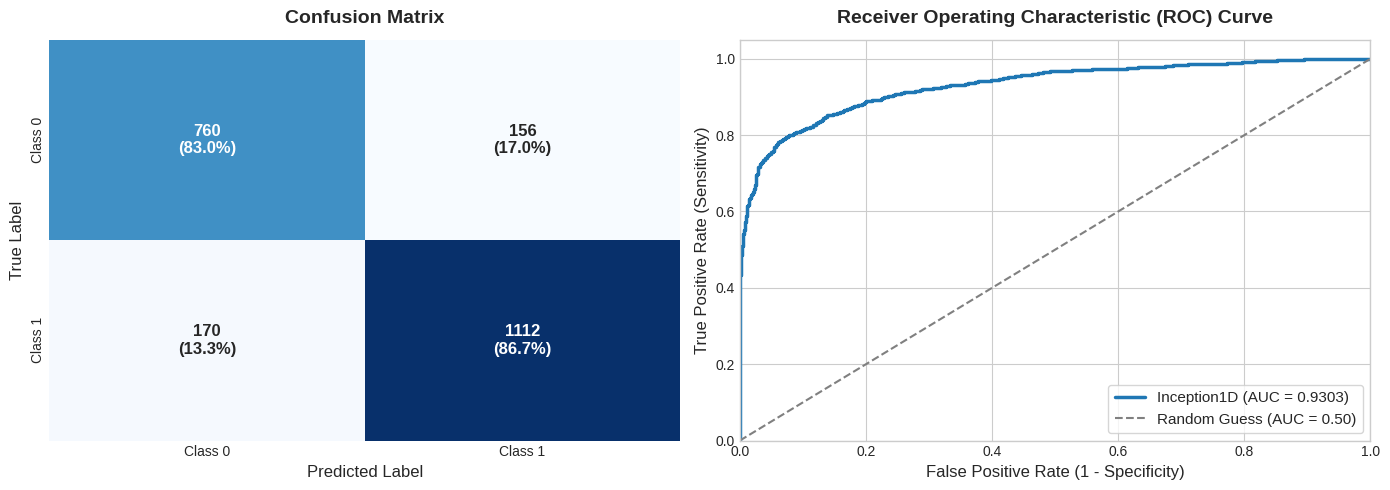

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


cm = confusion_matrix(all_targets, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = [f"{count}\n({percent:.1f}%)" for count, percent in zip(cm.flatten(), cm_percent.flatten())]
labels = np.array(labels).reshape(cm.shape)

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 12, "weight": "bold"}
)

axes[0].set_title('Confusion Matrix', fontsize=14, pad=12, weight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xticklabels(['Class 0', 'Class 1'] if is_binary else range(num_classes))
axes[0].set_yticklabels(['Class 0', 'Class 1'] if is_binary else range(num_classes))

if is_binary:
    fpr, tpr, _ = roc_curve(all_targets, all_probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Inception1D (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=12, weight='bold')
    axes[1].legend(loc="lower right", fontsize=11, frameon=True)
else:
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(all_targets, classes=list(range(num_classes)))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.3f})')

    axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('Multi-Class ROC Curve (One-vs-Rest)', fontsize=14, pad=12, weight='bold')
    axes[1].legend(loc="lower right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()